# Logistic Regression Model for Credit Card Fraud Detection

This notebook trains a logistic regression model to detect fraudulent credit card transactions.

## 1. Import Libraries

In [1]:
from pathlib import Path
import json

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    auc,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    precision_recall_curve,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.preprocessing import StandardScaler

## 2. Load and Explore Data

In [2]:
csv_path = Path("creditcard.csv")
if not csv_path.exists():
    raise FileNotFoundError(f"Could not find dataset at {csv_path}")

df = pd.read_csv(csv_path)
if "Class" not in df.columns:
    raise ValueError("Dataset must contain a 'Class' target column.")

print(f"Loaded dataset: {csv_path}")
print(f"Shape: {df.shape}")
print("Class distribution:")
print(df["Class"].value_counts())

Loaded dataset: creditcard.csv
Shape: (284807, 31)
Class distribution:
Class
0    284315
1       492
Name: count, dtype: int64


## 3. Prepare Features and Target

In [3]:
feature_columns = [column for column in df.columns if column != "Class"]
X = df[feature_columns].values
y = df["Class"].values

print(f"Number of features: {len(feature_columns)}")
print(f"Number of samples: {len(X)}")

Number of features: 30
Number of samples: 284807


## 4. Train-Test Split and Selective Scaling

Scale only Amount and Time (raw features). PCA-transformed features (V1-V28) are already scaled.

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

# Identify Amount and Time columns for selective scaling
scaling_columns = ['Amount', 'Time']
scaling_indices = [feature_columns.index(col) for col in scaling_columns if col in feature_columns]

# Scale only Amount and Time; leave PCA-transformed features (V1-V28) unchanged
scaler = StandardScaler()
X_train_scaled = X_train.copy().astype(float)
X_test_scaled = X_test.copy().astype(float)

if scaling_indices:
    X_train_scaled[:, scaling_indices] = scaler.fit_transform(X_train[:, scaling_indices])
    X_test_scaled[:, scaling_indices] = scaler.transform(X_test[:, scaling_indices])
    print(f"Scaled columns: {scaling_columns}")
else:
    print(f"Warning: Amount/Time columns not found in {feature_columns}")

print(f"Training set size: {len(X_train)}")
print(f"Test set size: {len(X_test)}")

Scaled columns: ['Amount', 'Time']
Training set size: 227845
Test set size: 56962


## 5. Model Training with Hyperparameter Tuning

Initialize model with class balancing on original (not oversampled) data.
Using both oversampling and class_weight often inflates false positives.

In [5]:
log_reg = LogisticRegression(
    class_weight="balanced",
    random_state=42,
    max_iter=1000,
    solver="liblinear",
)

# Hyperparameter tuning.
param_grid = {
    "C": [0.01, 0.1, 1, 10],
}

grid_search = GridSearchCV(
    log_reg,
    param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1,
)

grid_search.fit(X_train_scaled, y_train)

best_log_reg = grid_search.best_estimator_
print("Best parameters:", grid_search.best_params_)

Best parameters: {'C': 0.01}


## 6. Threshold Optimization for F1 Score

In [6]:
y_pred_proba_log = best_log_reg.predict_proba(X_test_scaled)[:, 1]

thresholds = np.linspace(0.1, 0.99, 100)
best_threshold = 0.5
best_f1 = 0.0

for threshold in thresholds:
    y_pred_adjusted = (y_pred_proba_log >= threshold).astype(int)
    f1 = f1_score(y_test, y_pred_adjusted)
    if f1 > best_f1:
        best_f1 = f1
        best_threshold = threshold

print(f"Best threshold: {best_threshold:.2f}")
y_pred_log_optimized = (y_pred_proba_log >= best_threshold).astype(int)

Best threshold: 0.99


## 7. Precision-Focused Operating Point

Maximize precision while keeping recall acceptable (min recall target: 70%).

In [7]:
min_recall_target = 0.70
precisions_curve, recalls_curve, pr_thresholds = precision_recall_curve(
    y_test, y_pred_proba_log
)
precision_best = 0.0
recall_at_precision_best = 0.0
precision_threshold = 0.99

for idx, threshold in enumerate(pr_thresholds):
    precision_value = precisions_curve[idx + 1]
    recall_value = recalls_curve[idx + 1]
    if recall_value >= min_recall_target and precision_value > precision_best:
        precision_best = precision_value
        recall_at_precision_best = recall_value
        precision_threshold = threshold

y_pred_precision_focused = (y_pred_proba_log >= precision_threshold).astype(int)
print(
    f"Precision-focused threshold: {precision_threshold:.4f} "
    f"(precision={precision_best:.4f}, recall={recall_at_precision_best:.4f}, "
    f"min_recall={min_recall_target:.2f})"
)

Precision-focused threshold: 1.0000 (precision=0.8478, recall=0.7959, min_recall=0.70)


## 8. Model Evaluation

In [8]:
print("=" * 50)
print("LOGISTIC REGRESSION RESULTS")
print("=" * 50)
print("\nClassification Report:")
print(classification_report(y_test, y_pred_precision_focused))
print(f"\nROC-AUC Score: {roc_auc_score(y_test, y_pred_proba_log):.4f}")

precision, recall, _ = precision_recall_curve(y_test, y_pred_proba_log)
pr_auc = auc(recall, precision)
print(f"Precision-Recall AUC: {pr_auc:.4f}")

LOGISTIC REGRESSION RESULTS

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.84      0.80      0.82        98

    accuracy                           1.00     56962
   macro avg       0.92      0.90      0.91     56962
weighted avg       1.00      1.00      1.00     56962


ROC-AUC Score: 0.9725
Precision-Recall AUC: 0.7520


## 9. Performance at Fixed Thresholds

In [9]:
fixed_thresholds = [0.5, 0.7, 0.9, 0.95]
print("Fraud precision/recall at fixed thresholds:")
print("Threshold | Precision (Class 1) | Recall (Class 1)")
for threshold in fixed_thresholds:
    y_pred_fixed = (y_pred_proba_log >= threshold).astype(int)
    fraud_precision = precision_score(y_test, y_pred_fixed, zero_division=0)
    fraud_recall = recall_score(y_test, y_pred_fixed, zero_division=0)
    print(f"{threshold:8.2f} | {fraud_precision:19.4f} | {fraud_recall:16.4f}")

Fraud precision/recall at fixed thresholds:
Threshold | Precision (Class 1) | Recall (Class 1)
    0.50 |              0.0616 |           0.9184
    0.70 |              0.1241 |           0.9082
    0.90 |              0.2582 |           0.8878
    0.95 |              0.4286 |           0.8878


## 10. Confusion Matrix Visualization

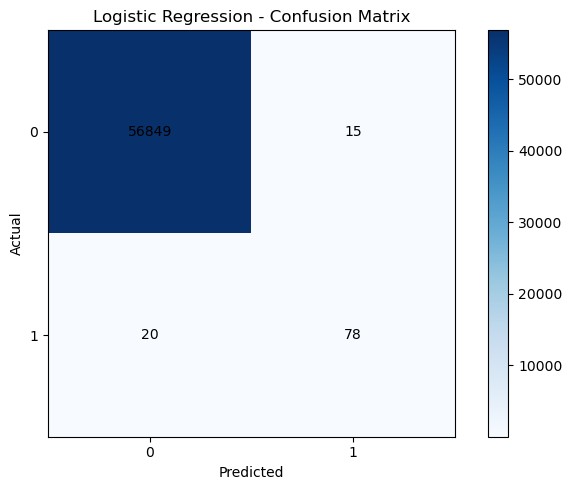

Confusion Matrix:
[[56849    15]
 [   20    78]]


In [10]:
cm = confusion_matrix(y_test, y_pred_precision_focused)
fig, ax = plt.subplots(figsize=(7, 5))
image = ax.imshow(cm, cmap="Blues")
plt.colorbar(image, ax=ax)
ax.set_title("Logistic Regression - Confusion Matrix")
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])

for (i, j), value in np.ndenumerate(cm):
    ax.text(j, i, str(value), ha="center", va="center", color="black")

plt.tight_layout()
plt.show()

print(f"Confusion Matrix:\n{cm}")

## 11. Save Model Artifacts

In [11]:
artifact_dir = Path(".")
model_path = artifact_dir / "logistic_model.joblib"
scaler_path = artifact_dir / "logistic_scaler.joblib"
metadata_path = artifact_dir / "logistic_model_meta.json"

joblib.dump(best_log_reg, model_path)
joblib.dump(scaler, scaler_path)
metadata = {
    "best_threshold": float(best_threshold),
    "precision_threshold": float(precision_threshold),
    "random_state": 42,
    "test_size": 0.2,
    "target_column": "Class",
    "feature_columns": feature_columns,
    "scaled_columns": scaling_columns,
    "scaling_note": "Only Amount and Time are scaled; PCA-transformed features (V1-V28) are left unchanged.",
}
metadata_path.write_text(json.dumps(metadata, indent=2), encoding="utf-8")

print(f"Model saved to: {model_path}")
print(f"Scaler saved to: {scaler_path}")
print(f"Metadata saved to: {metadata_path}")

Model saved to: logistic_model.joblib
Scaler saved to: logistic_scaler.joblib
Metadata saved to: logistic_model_meta.json


## 12. Quick Inference Test Script

Load saved artifacts and run a sample prediction to verify deployment readiness.

In [ ]:
loaded_model = joblib.load(model_path)
loaded_scaler = joblib.load(scaler_path)
loaded_metadata = json.loads(metadata_path.read_text(encoding="utf-8"))

test_idx = 0
sample_features = X_test[test_idx:test_idx + 1].copy().astype(float)

feature_columns_from_meta = loaded_metadata.get("feature_columns", feature_columns)
scaled_columns_from_meta = loaded_metadata.get("scaled_columns", [])
scaling_indices = [
    feature_columns_from_meta.index(col)
    for col in scaled_columns_from_meta
    if col in feature_columns_from_meta
]
if scaling_indices:
    sample_features[:, scaling_indices] = loaded_scaler.transform(
        sample_features[:, scaling_indices]
    )

sample_probability = loaded_model.predict_proba(sample_features)[0, 1]
decision_threshold = loaded_metadata.get(
    "precision_threshold", loaded_metadata.get("best_threshold", 0.5)
)
sample_prediction = int(sample_probability >= decision_threshold)
actual_label = int(y_test[test_idx])

print("Quick inference test")
print(f"Threshold used: {decision_threshold:.4f}")
print(f"Fraud probability: {sample_probability:.6f}")
print(f"Predicted label: {sample_prediction}")
print(f"Actual label: {actual_label}")